# Meesho Limited : IPO Analysis

A self-contained, re-runnable companion to the IPO research report. It ingests the reconciled
financial statements and **automatically computes** the financial ratios, valuation multiples and a
discounted-cash-flow valuation, then reproduces the core charts.

> All figures in ₹ crore unless stated. Sources: Meesho RHP/DRHP (SEBI), exchange data, and cited
> brokerage notes. Educational exercise — not investment advice.

**To update for a new quarter:** edit the dictionaries in *Section 1* and re-run all cells.

## 0. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

INK='#1E293B'; MAGENTA='#E5006D'; TEAL='#0E9F8E'; BLUE='#3B6EA5'; AMBER='#E0912F'
plt.rcParams.update({'figure.dpi':110,'font.size':11,'axes.spines.top':False,'axes.spines.right':False,
                     'axes.titleweight':'bold','axes.titlecolor':INK})
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Financial statements (inputs)
The only place you edit. Everything downstream is derived.

In [ ]:
# Income statement (Rs crore). None = not separately disclosed.
periods = ['FY23','FY24','FY25','H1FY26']
IS = {
    'revenue':        [5734.5, 7615.1, 9389.9, 5577.5],
    'logistics':      [4817.0, 5926.8, 7352.0, 4429.0],
    'advertising':    [ 928.0,  459.4,  643.5,  606.0],
    'employee':       [ np.nan, 757.7,  848.1,  np.nan],
    'total_expense':  [ np.nan, 8173.7, 10009.3, np.nan],
    'net_profit':     [-1671.9, -327.6, -3941.7, -700.7],
    'op_loss_ex_exc': [ np.nan, np.nan, -108.4, -433.0],   # ex-exceptional operating result
    'fcf':            [-2336.0, 304.0,  351.0,  np.nan],
    'nmv':            [ np.nan, np.nan, np.nan, 19194.0],
}
# Prior-period comparatives for YoY on half-year
REV_H1FY25 = 4311.3
# One-time items embedded in the FY25 loss
EXC_TAX_FY25, EXC_REORG_FY25 = 2487.3, 1346.0

# Operating metrics
OP = {
    'ATU_cr':      [13.64, np.nan, 19.88, 23.42],   # annual transacting users (crore)
    'orders_cr':   [np.nan, np.nan, 183.0, 126.1],
    'contrib_pct_nmv':[0.0294, np.nan, 0.0495, 0.0382],
    'cod_pct':     [0.8871, 0.8539, 0.7695, 0.72],
    'ftes':        [np.nan, np.nan, np.nan, 2082],
}
df = pd.DataFrame(IS, index=periods).T
df

,FY23,FY24,FY25,H1FY26
revenue,"5,734.50","7,615.10","9,389.90","5,577.50"
logistics,"4,817.00","5,926.80","7,352.00","4,429.00"
advertising,928.00,459.40,643.50,606.00
employee,NaN,757.70,848.10,NaN
total_expense,NaN,"8,173.70","10,009.30",NaN
net_profit,"-1,671.90",-327.60,"-3,941.70",-700.70
op_loss_ex_exc,NaN,NaN,-108.40,-433.00
fcf,"-2,336.00",304.00,351.00,NaN
nmv,NaN,NaN,NaN,"19,194.00"


## 2. Financial ratios (auto-computed)
Growth, margin, cost-structure and efficiency ratios.

In [ ]:
r = pd.DataFrame(index=periods)
rev = df.loc['revenue']
# Growth
r['revenue_YoY'] = [np.nan, rev['FY24']/rev['FY23']-1, rev['FY25']/rev['FY24']-1, rev['H1FY26']/REV_H1FY25-1]
# Margins
r['net_margin_reported']   = df.loc['net_profit']/rev
r['net_margin_ex_except']  = df.loc['op_loss_ex_exc']/rev
r['contrib_margin_%NMV']   = OP['contrib_pct_nmv']
# Cost ratios
r['logistics_/_rev']   = df.loc['logistics']/rev
r['advertising_/_rev'] = df.loc['advertising']/rev
r['employee_/_rev']    = df.loc['employee']/rev
r['fcf_margin']        = df.loc['fcf']/rev
r = r.T
rev_cagr = (rev['FY25']/rev['FY23'])**(1/2)-1
print(f'Revenue CAGR FY23-FY25: {rev_cagr:.1%}')
(r*100).round(1).astype(str) + '%'

Revenue CAGR FY23-FY25: 28.0%


,FY23,FY24,FY25,H1FY26
revenue_YoY,nan%,32.8%,23.3%,29.4%
net_margin_reported,-29.2%,-4.3%,-42.0%,-12.6%
net_margin_ex_except,nan%,nan%,-1.2%,-7.8%
contrib_margin_%NMV,2.9%,nan%,5.0%,3.8%
logistics_/_rev,84.0%,77.8%,78.3%,79.4%
advertising_/_rev,16.2%,6.0%,6.9%,10.9%
employee_/_rev,nan%,9.9%,9.0%,nan%
fcf_margin,-40.7%,4.0%,3.7%,nan%


In [ ]:
# Efficiency / per-unit
rev_per_emp = rev['FY25']/OP['ftes'][3]      # FY25 revenue over FTEs
contrib_per_order = 8.09                       # Rs/order, per RHP (FY25)
print(f'Revenue per employee (FY25):  Rs {rev_per_emp:,.1f} cr')
print(f'Contribution per order (FY25): Rs {contrib_per_order:.2f}')
print(f'CoD share FY23 -> H1FY26: {OP["cod_pct"][0]:.0%} -> {OP["cod_pct"][3]:.0%}')

Revenue per employee (FY25):  Rs 4.5 cr
Contribution per order (FY25): Rs 8.09
CoD share FY23 -> H1FY26: 89% -> 72%


## 3. Valuation multiples
At the ₹111 issue price and at the current market price, plus a listed-peer table.

In [ ]:
SHARES_CR = 451.31            # crore shares (mcap 50,096 / 111)
issue_price, current_price = 111.0, 192.0
mcap_issue   = issue_price*SHARES_CR
mcap_current = current_price*SHARES_CR
ps_issue   = mcap_issue/rev['FY25']
ps_current = mcap_current/rev['FY25']
mcap_per_user = mcap_issue/OP['ATU_cr'][2]*1  # Rs cr / crore users -> Rs per user (crore cancels)
print(f'Market cap  @issue Rs {mcap_issue:,.0f} cr  | @current Rs {mcap_current:,.0f} cr')
print(f'P/S (FY25 rev)  @issue {ps_issue:.1f}x  | @current {ps_current:.1f}x')
print(f'Market cap / annual user (@issue): Rs {mcap_per_user:,.0f}')

Market cap  @issue Rs 50,095 cr  | @current Rs 86,652 cr
P/S (FY25 rev)  @issue 5.3x  | @current 9.2x
Market cap / annual user (@issue): Rs 2,520


In [ ]:
peers = pd.DataFrame([
    ['Meesho','Value marketplace',9389.9,'FY25','Near-BE',86750],
    ['Eternal (Zomato)','Food + q-comm',20000,'FY26E','Yes',240000],
    ['Swiggy','Food + q-comm',15227,'FY25','No',58000],
    ['Nykaa (FSN)','Beauty/fashion',10022,'FY26','Yes',88500],
    ['FirstCry (Brainbees)','Kids & baby',7660,'FY25','Marginal',11772],
    ['DMart (Avenue)','Value retail',59000,'FY25','Yes',270000],
], columns=['Company','Model','Revenue_cr','Rev_yr','Profitable','Mcap_cr'])
peers['P/S'] = (peers['Mcap_cr']/peers['Revenue_cr']).round(1)
peers

,Company,Model,Revenue_cr,Rev_yr,Profitable,Mcap_cr,P/S
0,Meesho,Value marketplace,"9,389.90",FY25,Near-BE,86750,9.20
1,Eternal (Zomato),Food + q-comm,"20,000.00",FY26E,Yes,240000,12.00
2,Swiggy,Food + q-comm,"15,227.00",FY25,No,58000,3.80
3,Nykaa (FSN),Beauty/fashion,"10,022.00",FY26,Yes,88500,8.80
4,FirstCry (Brainbees),Kids & baby,"7,660.00",FY25,Marginal,11772,1.50
5,DMart (Avenue),Value retail,"59,000.00",FY25,Yes,270000,4.60


## 4. Discounted cash flow (FCFF)
Ten-year explicit forecast + Gordon terminal value. Edit the assumptions and re-run.

In [ ]:
REV0   = 9389.9
GROWTH = [.30,.28,.25,.22,.20,.18,.16,.14,.12,.10]   # revenue growth fade
FCFM   = [.02,.04,.06,.08,.10,.12,.14,.16,.18,.20]   # FCF margin ramp
NET_CASH, SHARES = 2500.0, 451.31

def dcf(wacc=0.13, g=0.05, rev0=REV0, growth=GROWTH, fcfm=FCFM, net_cash=NET_CASH, shares=SHARES, detail=False):
    rows=[]; rev=rev0
    pv_sum=0.0; fcff_last=0.0
    for i in range(len(growth)):
        rev*= (1+growth[i]); fcff=rev*fcfm[i]; df_=1/(1+wacc)**(i+1); pv=fcff*df_
        pv_sum+=pv; fcff_last=fcff
        rows.append([f'FY{26+i}E', rev, fcff, df_, pv])
    tv = fcff_last*(1+g)/(wacc-g)
    pv_tv = tv/(1+wacc)**len(growth)
    ev = pv_sum+pv_tv; eq = ev+net_cash; fv = eq/shares
    if detail:
        proj=pd.DataFrame(rows, columns=['Year','Revenue','FCFF','DiscFactor','PV_FCFF']).set_index('Year')
        return fv, ev, eq, pv_tv, proj
    return fv

fv, ev, eq, pv_tv, proj = dcf(detail=True)
print(f'Enterprise value: Rs {ev:,.0f} cr')
print(f'Equity value:     Rs {eq:,.0f} cr  (incl. net cash Rs {NET_CASH:,.0f} cr)')
print(f'PV of terminal value: Rs {pv_tv:,.0f} cr  ({pv_tv/ev:.0%} of EV)')
print(f'BASE-CASE FAIR VALUE: Rs {fv:,.1f} / share   (issue Rs 111 | current Rs 192)')
proj.round(0)

Enterprise value: Rs 59,938 cr
Equity value:     Rs 62,438 cr  (incl. net cash Rs 2,500 cr)
PV of terminal value: Rs 42,508 cr  (71% of EV)
BASE-CASE FAIR VALUE: Rs 138.3 / share   (issue Rs 111 | current Rs 192)


,Revenue,FCFF,DiscFactor,PV_FCFF
Year,,,,
FY26E,"12,207.00",244.00,1.00,216.00
FY27E,"15,625.00",625.00,1.00,489.00
FY28E,"19,531.00","1,172.00",1.00,812.00
FY29E,"23,828.00","1,906.00",1.00,"1,169.00"
FY30E,"28,593.00","2,859.00",1.00,"1,552.00"
FY31E,"33,740.00","4,049.00",0.00,"1,945.00"
FY32E,"39,139.00","5,479.00",0.00,"2,329.00"
FY33E,"44,618.00","7,139.00",0.00,"2,685.00"
FY34E,"49,972.00","8,995.00",0.00,"2,994.00"


## 5. Sensitivity analysis
Fair value per share across WACC × terminal growth. The FCFF stream is fixed, so only discounting changes.

Implied fair value per share (Rs):


,3.0%,4.0%,5.0%,5.5%,6.0%
12%,136.00,149.00,164.00,174.00,185.00
13%,118.00,127.00,138.00,145.00,153.00
14%,103.00,110.00,118.00,123.00,129.00
15%,91.00,97.00,103.00,106.00,111.00
16%,81.00,85.00,90.00,93.00,96.00


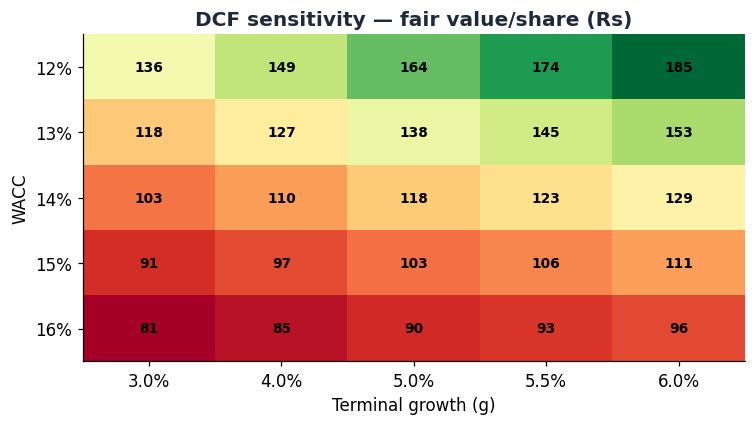

In [ ]:
waccs=[0.12,0.13,0.14,0.15,0.16]; gs=[0.03,0.04,0.05,0.055,0.06]
grid=pd.DataFrame([[dcf(w,g) for g in gs] for w in waccs],
                  index=[f'{w:.0%}' for w in waccs], columns=[f'{g:.1%}' for g in gs])
print('Implied fair value per share (Rs):'); display(grid.round(0))

fig,ax=plt.subplots(figsize=(7,4))
im=ax.imshow(grid.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(gs))); ax.set_xticklabels(grid.columns)
ax.set_yticks(range(len(waccs))); ax.set_yticklabels(grid.index)
ax.set_xlabel('Terminal growth (g)'); ax.set_ylabel('WACC'); ax.set_title('DCF sensitivity — fair value/share (Rs)')
for i in range(len(waccs)):
    for j in range(len(gs)):
        ax.text(j,i,f'{grid.values[i,j]:.0f}',ha='center',va='center',fontsize=9,fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Charts from the financial statements

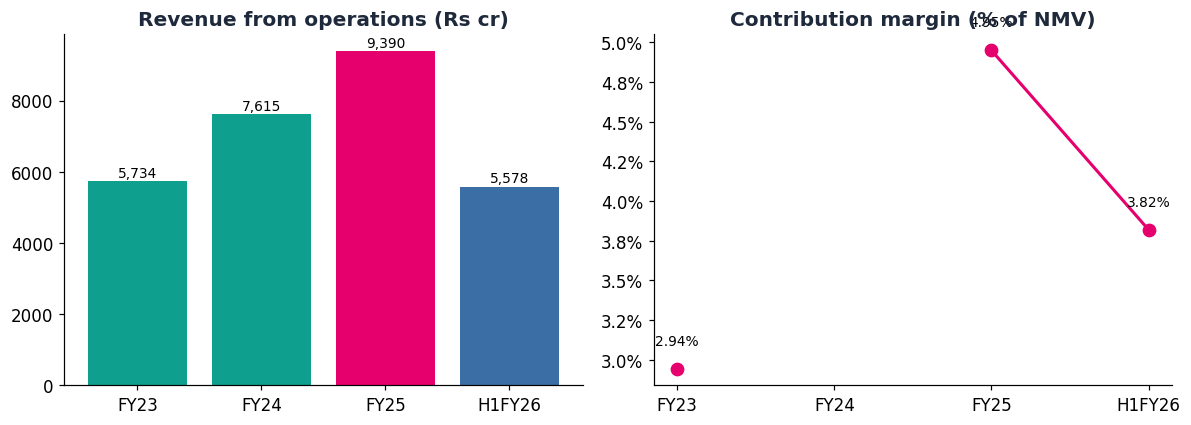

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
# Revenue
axes[0].bar(periods, rev.values, color=[TEAL,TEAL,MAGENTA,BLUE])
axes[0].set_title('Revenue from operations (Rs cr)')
for i,v in enumerate(rev.values): axes[0].text(i,v+120,f'{v:,.0f}',ha='center',fontsize=9)
# Contribution margin
cm=[x*100 if not np.isnan(x) else np.nan for x in OP['contrib_pct_nmv']]
axes[1].plot(periods, cm, 'o-', color=MAGENTA, lw=2, ms=8)
axes[1].set_title('Contribution margin (% of NMV)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
for i,v in enumerate(cm):
    if not np.isnan(v): axes[1].text(i,v+0.15,f'{v:.2f}%',ha='center',fontsize=9)
plt.tight_layout(); plt.show()

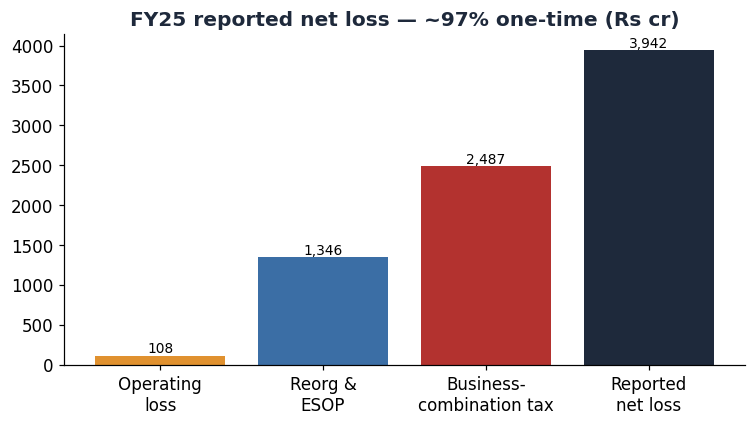

One-time share of FY25 loss: 97%


In [ ]:
# FY25 reported loss decomposition
op_loss=108.4; parts=['Operating\nloss','Reorg &\nESOP','Business-\ncombination tax','Reported\nnet loss']
vals=[op_loss, EXC_REORG_FY25, EXC_TAX_FY25, 3941.7]
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(parts[:3], vals[:3], color=[AMBER,BLUE,'#B3322F'])
ax.bar(parts[3], vals[3], color=INK)
ax.set_title('FY25 reported net loss — ~97% one-time (Rs cr)')
for i,v in enumerate(vals): ax.text(i,v+40,f'{v:,.0f}',ha='center',fontsize=9)
plt.tight_layout(); plt.show()
print(f'One-time share of FY25 loss: {(EXC_TAX_FY25+EXC_REORG_FY25)/3941.7:.0%}')

---
### Key takeaways (auto-derived)
- Revenue compounding at ~28% (FY23–FY25); H1 FY26 up ~29% YoY.
- FY25 reported loss is ~97% one-time items; **ex-exceptional operating margin ≈ −1%** — near breakeven.
- Positive free cash flow since FY24; net debt-free.
- Base-case DCF ≈ **₹138/share** vs ₹111 issue and ~₹192 current; sensitivity ₹81–₹185.

*Educational exercise. Verify against the RHP before any decision.*